# V27: AI Strategy Implementation for Indonesia Stock Market (LQ45 / IHSG)

This notebook adapts the **AI-Gated Markowitz Strategy** with transaction costs for the Indonesian stock market, specifically focusing on **LQ45** liquid stocks and using **IHSG** as a market benchmark.

### Key Adaptations for LQ45/IHSG:
1. **Transaction Fees**: Adjusted to a more realistic **0.25%** per turnover (common in Indo stock brokers).
2. **Market Regime**: AI trained to predict the next day trend of the IHSG index (or the proxy of the portfolio).
3. **Graph Filtering**: Using Independent Set to pick stocks with low cross-correlations in the Indonesian market.
4. **Benchmarking**: Comparing against the LQ45 Index / IHSG (Buy and Hold).

In [5]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45 Dataset) ---
# Note: Change the filename to your actual LQ45 excel file
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    # Falling back to crypto dataset for logic testing if LQ45 file not found
    print("Warning: LQ45 dataset not found. Using crypto dataset as placeholder for logic demonstration.")
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1) # Representing the broader market (IHSG Proxy)

print(f"✓ Data Loaded: {len(data)} rows with {len(data.columns)} assets")

✓ Data Loaded: 712 rows with 30 assets


In [6]:
# --- 2. Threshold Optimization on Training Data ---
def find_optimal_threshold(model, X, y, beta=0.5):
    probs = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.3, 0.8, 51)
    scores = [fbeta_score(y, (probs >= t).astype(int), beta=beta) for t in thresholds]
    best_idx = np.argmax(scores)
    return thresholds[best_idx], scores[best_idx]

print("Training AI Gatekeeper for Stock Market Prediction...")
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features = features.dropna()
target = (market_return.shift(-1) > 0).astype(int).reindex(features.index).fillna(0)

train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
opt_t, _ = find_optimal_threshold(xgb_model, X_train, y_train)
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimal IQ45-Market Threshold: {opt_t:.2f}")

Training AI Gatekeeper for Stock Market Prediction...
Optimal IQ45-Market Threshold: 0.57


In [7]:
# --- 4. Simulation Engine for LQ45 (Higher Fees) ---

def get_mis_assets(returns_window, correlation_threshold=0.4): # Slightly lower corr threshold for stocks
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    def neg_sharpe(weights):
        p_ret = np.sum(weights * mu)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -p_ret / p_vol if p_vol > 0.0001 else 0
    res = minimize(neg_sharpe, [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x))

def run_stock_simulation(test_dates, returns, ai_probs, threshold=0.5, fee=0.0025): # 0.25% for stock market
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    prev_weights = {}
    
    for i, date in enumerate(test_dates[:-1]):
        is_risk_off = ai_probs.loc[date] < threshold
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        if is_risk_off:
            weights = {'CASH': 1.0}
        else:
            selected = get_mis_assets(window_rets)
            weights = optimize_markowitz(window_rets[selected])
        
        # Turnover Tax & Fee calculation
        all_adj_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_adj_assets)
        cost = val * turnover * fee
        val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

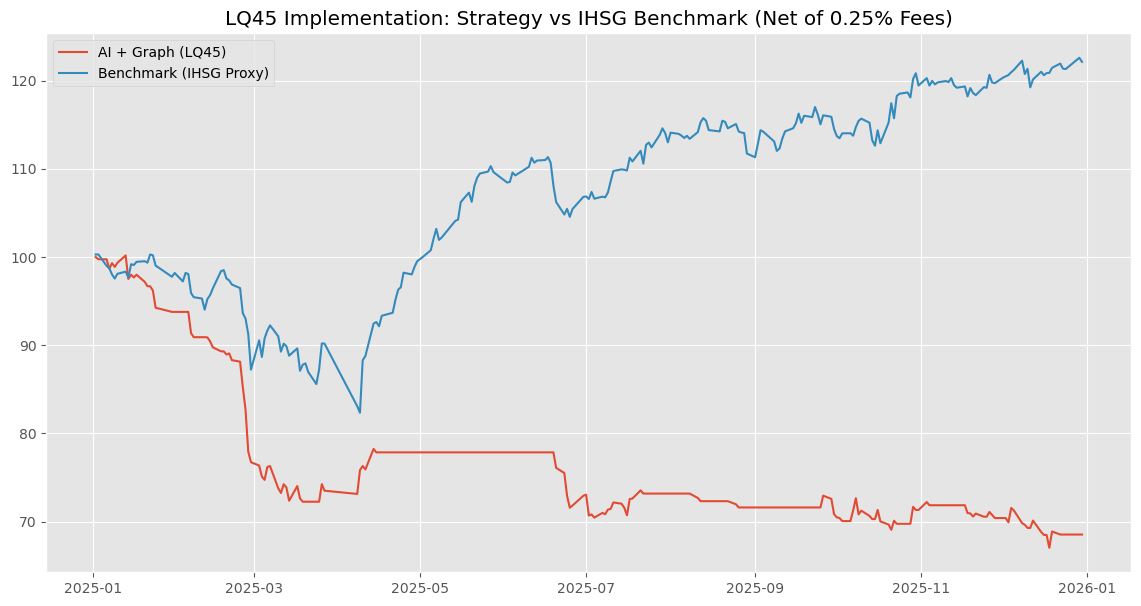

In [8]:
# --- 5. Backtest Comparison (LQ45 Simulation) ---
test_dates = test_probs.index
stock_fee = 0.0025 # 0.25% per turnover

results = {}
results['AI + Graph (LQ45)'] = run_stock_simulation(test_dates, returns, test_probs, threshold=opt_t, fee=stock_fee)
results['Benchmark (IHSG Proxy)'] = pd.DataFrame({'Portfolio_Value': (market_return.loc[test_dates].cumsum().apply(np.exp) * 100)}, index=test_dates)

plt.figure(figsize=(14, 7))
for label, df in results.items():
    plt.plot(df.index, df['Portfolio_Value'], label=label)

plt.title(f"LQ45 Implementation: Strategy vs IHSG Benchmark (Net of {stock_fee*100}% Fees)")
plt.legend()
plt.show()